In [2]:
import fastf1

fastf1.Cache.enable_cache("../data/cache")

In [3]:
session = fastf1.get_session(2024, "Monza", "Q")

session.load()

In [3]:
session.laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:16:12.142000,NOR,4,NaT,1.0,1.0,0 days 00:14:16.306000,NaT,NaT,0 days 00:00:37.116000,...,True,McLaren,0 days 00:14:16.306000,2024-08-31 14:03:14.075,1,NaN,False,,False,False
1,0 days 00:17:32.053000,NOR,4,0 days 00:01:19.911000,2.0,1.0,NaT,NaT,0 days 00:00:26.484000,0 days 00:00:26.898000,...,True,McLaren,0 days 00:16:12.142000,2024-08-31 14:05:09.911,1,NaN,False,,False,True
2,0 days 00:19:23.074000,NOR,4,0 days 00:01:51.021000,3.0,1.0,NaT,0 days 00:19:18.770000,0 days 00:00:32.371000,0 days 00:00:38.291000,...,True,McLaren,0 days 00:17:32.053000,2024-08-31 14:06:29.822,1,NaN,False,,False,False
3,0 days 00:43:29.375000,NOR,4,NaT,4.0,2.0,0 days 00:41:40.139000,NaT,NaT,0 days 00:00:39.008000,...,True,McLaren,0 days 00:19:23.074000,2024-08-31 14:08:20.843,12,NaN,False,,False,False
4,0 days 00:44:49.102000,NOR,4,0 days 00:01:19.727000,5.0,2.0,NaT,NaT,0 days 00:00:26.395000,0 days 00:00:26.865000,...,True,McLaren,0 days 00:43:29.375000,2024-08-31 14:32:27.144,1,NaN,False,,False,True


In [4]:
lap = session.laps.pick_drivers("LEC").pick_fastest().get_telemetry()
lap

,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2024-08-31 15:03:09.836,0 days 01:14:12.067000,,NaN,0 days 00:00:00,11468.635727,322.00,8,99.617857,False,8,interpolation,-0.035548,-0.000006,OnTrack,-1372.917895,-681.198488,1871.929905
3,2024-08-31 15:03:09.909,0 days 01:14:12.140000,,NaN,0 days 00:00:00.073000,11482.714286,322.00,8,99.357143,False,8,pos,6.494872,0.001126,OnTrack,-1369.000000,-619.000000,1872.000000
4,2024-08-31 15:03:09.929,0 days 01:14:12.160000,,NaN,0 days 00:00:00.093000,11486.571429,322.00,8,99.285714,False,8,pos,8.287603,0.001437,OnTrack,-1368.000000,-602.000000,1872.000000
5,2024-08-31 15:03:10.009,0 days 01:14:12.240000,,NaN,0 days 00:00:00.173000,11502.000000,322.00,8,99.000000,False,14,car,15.473889,0.002683,OnTrack,-1363.656966,-538.559027,1872.003638
6,2024-08-31 15:03:10.248,0 days 01:14:12.479000,,NaN,0 days 00:00:00.412000,11562.000000,325.00,8,100.000000,False,14,car,37.050278,0.006425,OnTrack,-1344.277325,-335.748315,1872.618098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618,2024-08-31 15:04:28.849,0 days 01:15:31.080000,,NaN,0 days 00:01:19.013000,11324.000000,318.00,8,100.000000,False,8,car,5720.116111,0.991959,OnTrack,-1405.913803,-1069.686410,1869.720739
619,2024-08-31 15:04:28.929,0 days 01:15:31.160000,,NaN,0 days 00:01:19.093000,11347.500000,318.75,8,100.000000,False,8,pos,5727.229150,0.993193,OnTrack,-1402.000000,-1019.000000,1870.000000
620,2024-08-31 15:04:29.169,0 days 01:15:31.400000,,NaN,0 days 00:01:19.333000,11418.000000,321.00,8,100.000000,False,8,car,5748.649444,0.996907,OnTrack,-1385.443628,-817.021830,1870.750891
621,2024-08-31 15:04:29.229,0 days 01:15:31.460000,,NaN,0 days 00:01:19.393000,11417.100000,321.00,8,100.000000,False,8,pos,5754.002108,0.997836,OnTrack,-1381.000000,-763.000000,1871.000000


In [5]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
# graph the track as a 3d render
tel = lap

x = tel["X"] / 10   # tenths of a meter → meters
y = tel["Y"] / 10
z = tel["Z"] / 10

fig = go.Figure(
    go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode="lines",
        line=dict(
            color=tel["Speed"],
            colorscale="Plasma",
            width=5,
            colorbar=dict(
                title="Speed (km/h)",
                thickness=15,
            ),
        ),
        # This adds a hover box showing the exact speed at any point on the track
        hovertemplate="X: %{x}<br>Y: %{y}<br>Z: %{z}<br>Speed: %{text} km/h<extra></extra>",
        text=tel["Speed"],
    )
)

fig.update_layout(
    scene=dict(
        aspectmode="data",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
    ),
    title=dict(
        text="FastF1 3D Telemetry Track Map",
        x=0.5,
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()

In [6]:
import pandas as pd
export = pd.DataFrame({
    "time":     tel["Time"].dt.total_seconds(),
    "x":        tel["X"] / 10,
    "y":        tel["Y"] / 10,
    "z":        tel["Z"] / 10,
    "speed":    tel["Speed"],
    "throttle": tel["Throttle"],
    "brake":    tel["Brake"].astype(int),
    "gear":     tel["nGear"],
})
# Make time start at 0
export["time"] = export["time"] - export["time"].iloc[0]

export.head()

,time,x,y,z,speed,throttle,brake,gear
2,0.000,-137.291789,-68.119849,187.192991,322.0,99.617857,0,8
3,0.073,-136.900000,-61.900000,187.200000,322.0,99.357143,0,8
4,0.093,-136.800000,-60.200000,187.200000,322.0,99.285714,0,8
5,0.173,-136.365697,-53.855903,187.200364,322.0,99.000000,0,8
6,0.412,-134.427733,-33.574831,187.261810,325.0,100.000000,0,8


In [8]:
export.to_csv("../data/samples/f1_monza_lec_q.csv", index=False)

In [4]:
%load_ext autoreload
%autoreload 2
from telemetry.f1 import load_session
session = load_session(2024, "Monza", "R")
session.laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:57:18.931000,LEC,16,0 days 00:01:28.179000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:29.989000,...,True,Ferrari,0 days 00:55:50.494000,2024-09-01 13:03:34.413,1,2.0,False,,False,False
1,0 days 00:58:44.327000,LEC,16,0 days 00:01:25.396000,2.0,1.0,NaT,NaT,0 days 00:00:27.707000,0 days 00:00:29.265000,...,True,Ferrari,0 days 00:57:18.931000,2024-09-01 13:05:02.850,1,2.0,False,,False,True
2,0 days 01:00:09.506000,LEC,16,0 days 00:01:25.179000,3.0,1.0,NaT,NaT,0 days 00:00:27.679000,0 days 00:00:29.001000,...,True,Ferrari,0 days 00:58:44.327000,2024-09-01 13:06:28.246,1,2.0,False,,False,True
3,0 days 01:01:34.316000,LEC,16,0 days 00:01:24.810000,4.0,1.0,NaT,NaT,0 days 00:00:27.653000,0 days 00:00:28.883000,...,True,Ferrari,0 days 01:00:09.506000,2024-09-01 13:07:53.425,1,2.0,False,,False,True
4,0 days 01:02:58.919000,LEC,16,0 days 00:01:24.603000,5.0,1.0,NaT,NaT,0 days 00:00:27.630000,0 days 00:00:28.790000,...,True,Ferrari,0 days 01:01:34.316000,2024-09-01 13:09:18.235,1,2.0,False,,False,True


In [7]:
from telemetry.f1 import get_driver_telemetry, to_standard_format

tel = get_driver_telemetry(session, "LEC")
std = to_standard_format(tel, "LEC")

std.head()
std.dtypes
std.describe()

,time,x,y,z,speed,throttle,brake,gear,rpm,drs
count,30637.000000,30637.000000,30637.000000,30637.000000,30043.000000,30043.000000,30043.0,30043.0,30043.000000,30043.0
mean,3993.483185,162.148112,455.410327,170.139423,150.975968,58.968212,0.236195,3.836667,7157.924142,0.79546
std,2290.501651,382.890603,634.312605,58.033249,129.494559,46.514693,0.42475,3.265515,4724.852209,2.158213
min,29.869000,-150.000000,-580.100000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0
25%,2016.629000,-132.200000,-7.800000,187.300000,0.000000,0.000000,0.0,0.0,1990.000000,0.0
50%,3988.630000,0.000000,143.700000,187.600000,176.000000,99.000000,0.0,5.0,10084.000000,0.0
75%,5972.670000,268.200000,1037.800000,192.500000,281.000000,100.000000,0.0,7.0,11190.000000,1.0
max,7970.451000,1106.800000,1588.300000,196.700000,347.000000,104.000000,1.0,8.0,12322.000000,14.0


In [9]:
from telemetry.f1 import build_race_replay

replay = build_race_replay(session)

print("Rows:", len(replay))
print("Drivers:", replay["vehicle_id"].nunique())
print("Time range:", replay["time"].min(), "to", replay["time"].max())

Rows: 360500
Drivers: 20
Time range: -59.96399999999994 to 4619.957


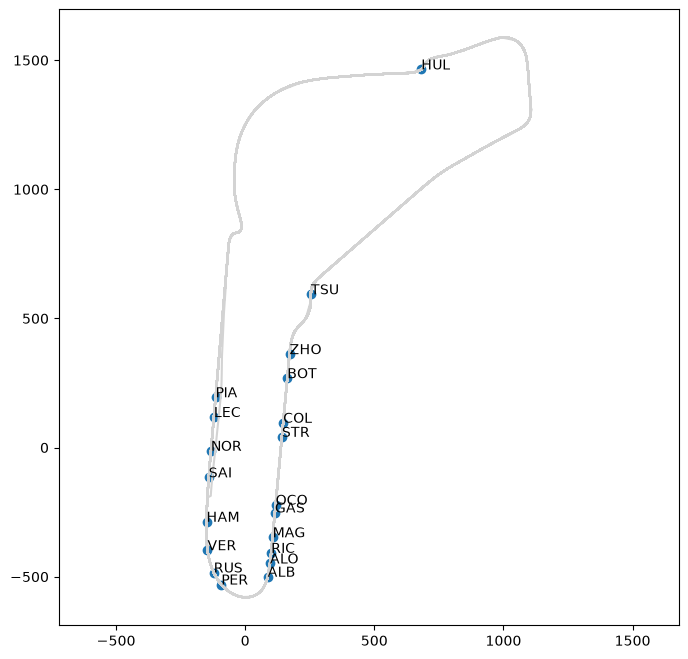

In [10]:
import matplotlib.pyplot as plt

t = 600  # 10 minutes into the session
snap = replay[(replay["time"] > t - 0.5) & (replay["time"] < t + 0.5)]
snap = snap.groupby("vehicle_id").first()

plt.figure(figsize=(8, 8))
plt.plot(replay[replay["vehicle_id"] == "LEC"]["x"],
         replay[replay["vehicle_id"] == "LEC"]["y"], color="lightgray")
plt.scatter(snap["x"], snap["y"])
for code, row in snap.iterrows():
    plt.annotate(code, (row["x"], row["y"]))
plt.axis("equal")
plt.show()

In [6]:
from telemetry.f1 import get_driver_telemetry

tel = get_driver_telemetry(session, "LEC")
print(len(tel))
tel

30637


,SessionTime,X,Y,Z,Status,Speed,Throttle,Brake,nGear,RPM,DRS
0,0 days 00:00:29.869000,0.0,0.0,0.0,OnTrack,NaN,NaN,NaN,NaN,NaN,NaN
1,0 days 00:00:30.209000,0.0,0.0,0.0,OnTrack,NaN,NaN,NaN,NaN,NaN,NaN
2,0 days 00:00:30.429000,0.0,0.0,0.0,OnTrack,NaN,NaN,NaN,NaN,NaN,NaN
3,0 days 00:00:30.829000,0.0,0.0,0.0,OnTrack,NaN,NaN,NaN,NaN,NaN,NaN
4,0 days 00:00:31.049000,0.0,0.0,0.0,OnTrack,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
30632,0 days 02:12:49.171000,5715.0,9069.0,1883.0,OnTrack,116.0,0.0,False,4.0,7123.0,0.0
30633,0 days 02:12:49.451000,5637.0,9001.0,1881.0,OnTrack,115.0,0.0,False,4.0,7263.0,0.0
30634,0 days 02:12:49.771000,5571.0,8944.0,1879.0,OnTrack,113.0,0.0,False,4.0,7016.0,0.0
30635,0 days 02:12:50.071000,5477.0,8862.0,1877.0,OnTrack,111.0,0.0,False,4.0,6888.0,0.0
